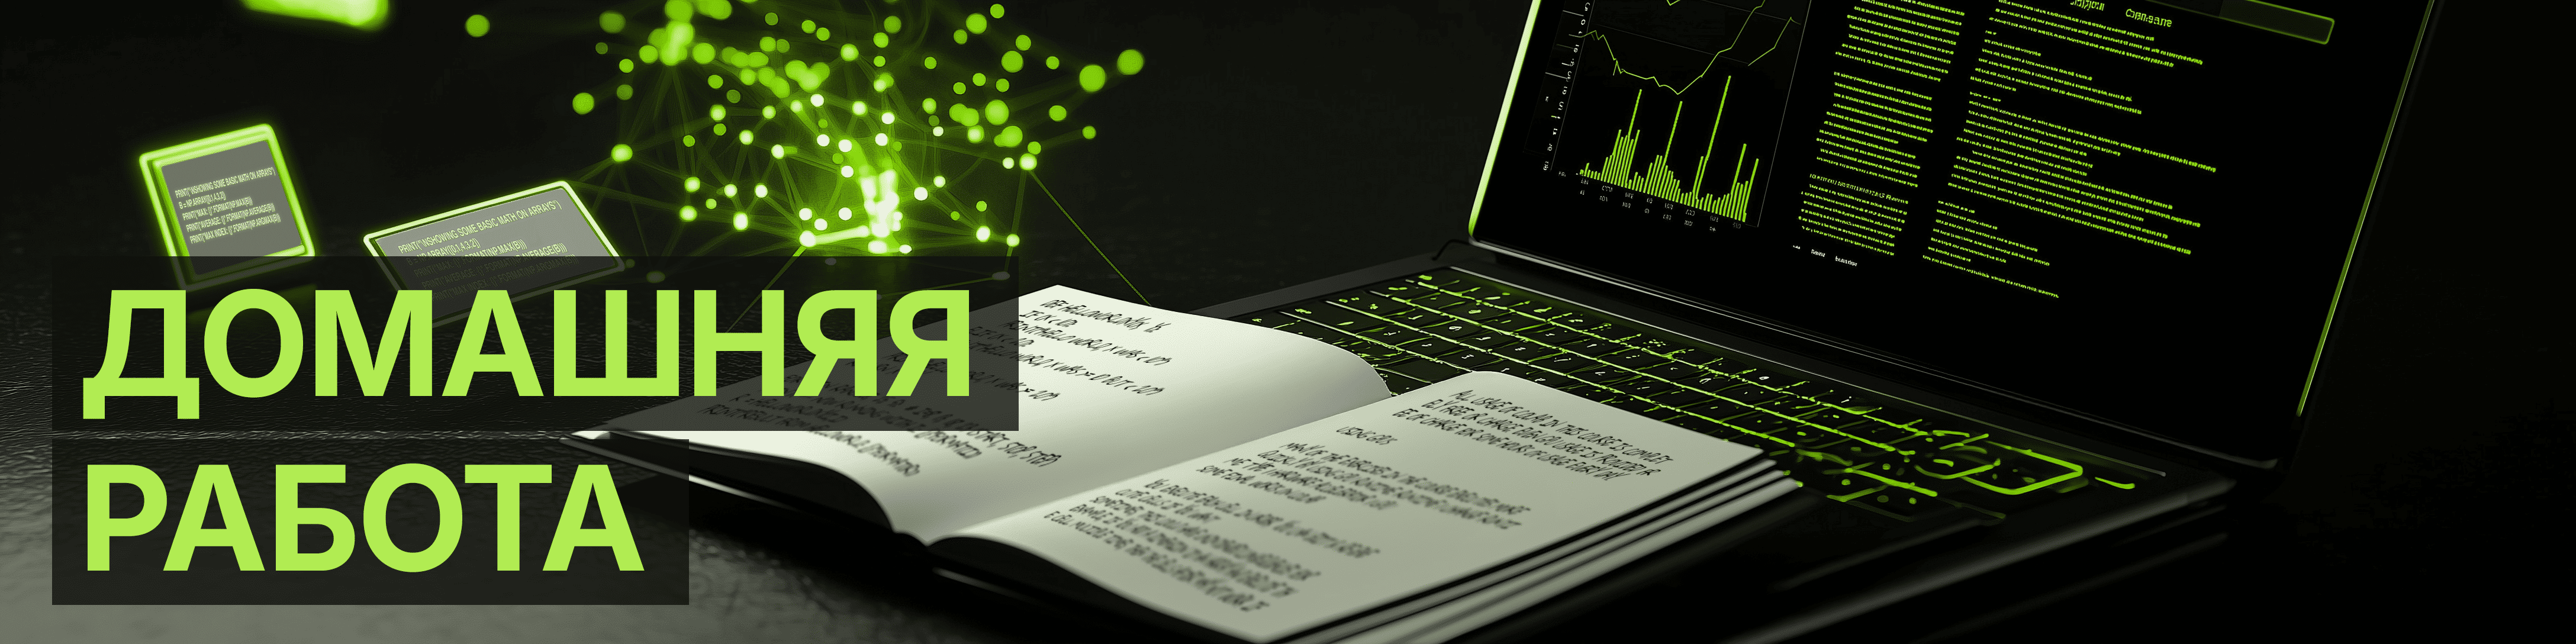

**Навигация по уроку**
1. [Семантическая сегментация изображений](https://colab.research.google.com/drive/10Zl8P7-YLFr9kXdjnvUuXDkruFBSFrlc)
2. [Практическая реализация модели сегментации](https://colab.research.google.com/drive/1yFPXLtKKTQcnOAy6JO3FYHdTbOAGtprR)
3. [Мультиклассовая сегментация](https://colab.research.google.com/drive/1Fy26vjAZPOVTOh8ZLnUYHiev3jD7J4Sh)
4. Домашняя работа

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:


**Задание 1. На 3 балла:**

1. Ваша задача используя модель и датасет из третей части урока, самостоятельно познакомиться с библиотекой [Albumentations](https://albumentations.ai/) и применить несколько методов аугментации для семантической сегментации снимков с беспилотника.

2. Используйте коллбэк функцию для предварительной остановки процесса обучения. Подумайте: какие параметры для остановки вы применили и почему?


**Задание 2. На 4 балла:**

1. Ваша задача зарегистрироваться на платформе по проведению соревнований в сфере машинного обучения [kaggle](https://www.kaggle.com/).
2. Загрузить датасет с данными о радиографическом ислледовании по COVID-19:

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as op
op.download("https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/")

3. Обучить U-net подобную архитектуру сегментировать легкие человека на радиографическом снимке. Используйте данные о нормальном состоянии легких в папке `covid19-radiography-database/COVID-19_Radiography_Dataset/Normal`.

4. Отобразите по 10 снимков с оригинальным изображением, оригинальной маской и предсказанной маской.

**Задание 3. На 5 балла:**

1. Самостоятельно изучите модель [U-net++](https://arxiv.org/pdf/1807.10165.pdf). Найдите ее архитектуру, в интернете множество статей с готовой архитектурой на TensorFlow и Keras.
2. Выполните задание 2 для датасета с нормальным состоянием легких используя модель U-net++.


100%|██████████| 778M/778M [00:37<00:00, 22.0MB/s]

Extracting files...


Датасет загружен.
Путь: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5
Корневая папка:
/root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5

COVID-19_Radiography_Dataset
Images: True
Masks: True
Путь к изображениям: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Normal/images
Путь к маскам: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Normal/masks
Изображений: 10192
Масок: 10192
Корректных пар: 10192

Normal-1.png → Normal-1.png
Normal-10.png → Normal-10.png
Normal-100.png → Normal-100.png
Normal-1000.png → Normal-1000.png
Normal-10000.png → Normal-10000.png


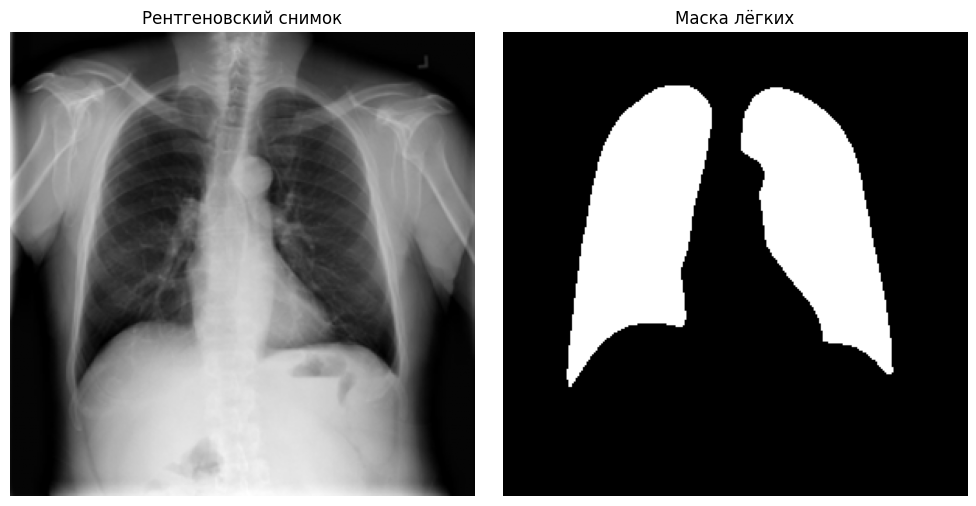

Размер изображения: (299, 299)
Размер маски: (256, 256, 3)


In [2]:
# 1. Установка зависимостей

%pip install -q kagglehub


# 2. Импорты

from pathlib import Path
import random

import kagglehub
import matplotlib.pyplot as plt
import numpy as np


# 3. Загрузка датасета

dataset_path = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

ROOT_DIR = Path(
    dataset_path
)

print("Датасет загружен.")
print("Путь:", ROOT_DIR)


# 4. Проверка структуры датасета

if not ROOT_DIR.exists():
    raise RuntimeError(
        "Папка датасета не найдена."
    )

print("Корневая папка:")
print(ROOT_DIR)
print()

for path in ROOT_DIR.iterdir():
    print(path.name)



# 5. Данные Normal

DATA_DIR = (
    ROOT_DIR
    / "COVID-19_Radiography_Dataset"
    / "Normal"
)

IMAGE_DIR = (
    DATA_DIR
    / "images"
)

MASK_DIR = (
    DATA_DIR
    / "masks"
)

print(
    "Images:",
    IMAGE_DIR.exists()
)

print(
    "Masks:",
    MASK_DIR.exists()
)

print(
    "Путь к изображениям:",
    IMAGE_DIR
)

print(
    "Путь к маскам:",
    MASK_DIR
)


# 6. Список файлов

image_paths = sorted(
    IMAGE_DIR.glob("*.png")
)

mask_paths = sorted(
    MASK_DIR.glob("*.png")
)

print(
    "Изображений:",
    len(image_paths)
)

print(
    "Масок:",
    len(mask_paths)
)


# 7. Проверка пар изображение-маска

mask_by_name = {
    path.name: path
    for path in mask_paths
}

pairs = []

for image_path in image_paths:

    mask_path = mask_by_name.get(
        image_path.name
    )

    if mask_path is not None:
        pairs.append(
            (
                image_path,
                mask_path,
            )
        )

print(
    "Корректных пар:",
    len(pairs)
)

print()

for image_path, mask_path in pairs[:5]:

    print(
        image_path.name,
        "→",
        mask_path.name,
    )



# 8. Просмотр изображения и маски

image_path, mask_path = random.choice(
    pairs
)

image = plt.imread(
    image_path
)

mask = plt.imread(
    mask_path
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
)

axes[0].imshow(
    image,
    cmap="gray",
)

axes[0].set_title(
    "Рентгеновский снимок"
)

axes[1].imshow(
    mask,
    cmap="gray",
)

axes[1].set_title(
    "Маска лёгких"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print(
    "Размер изображения:",
    image.shape
)

print(
    "Размер маски:",
    mask.shape
)




Train: 1200
Validation: 200
Test: 100
Размер входа: (128, 128, 1)
Batch size: 8
Аугментация подготовлена.
Train batches: 150
Validation batches: 25
Test batches: 13
Images: (8, 128, 128, 1)
Masks: (8, 128, 128, 1)
Image min/max: 0.0 1.0
Mask values: [0. 1.]


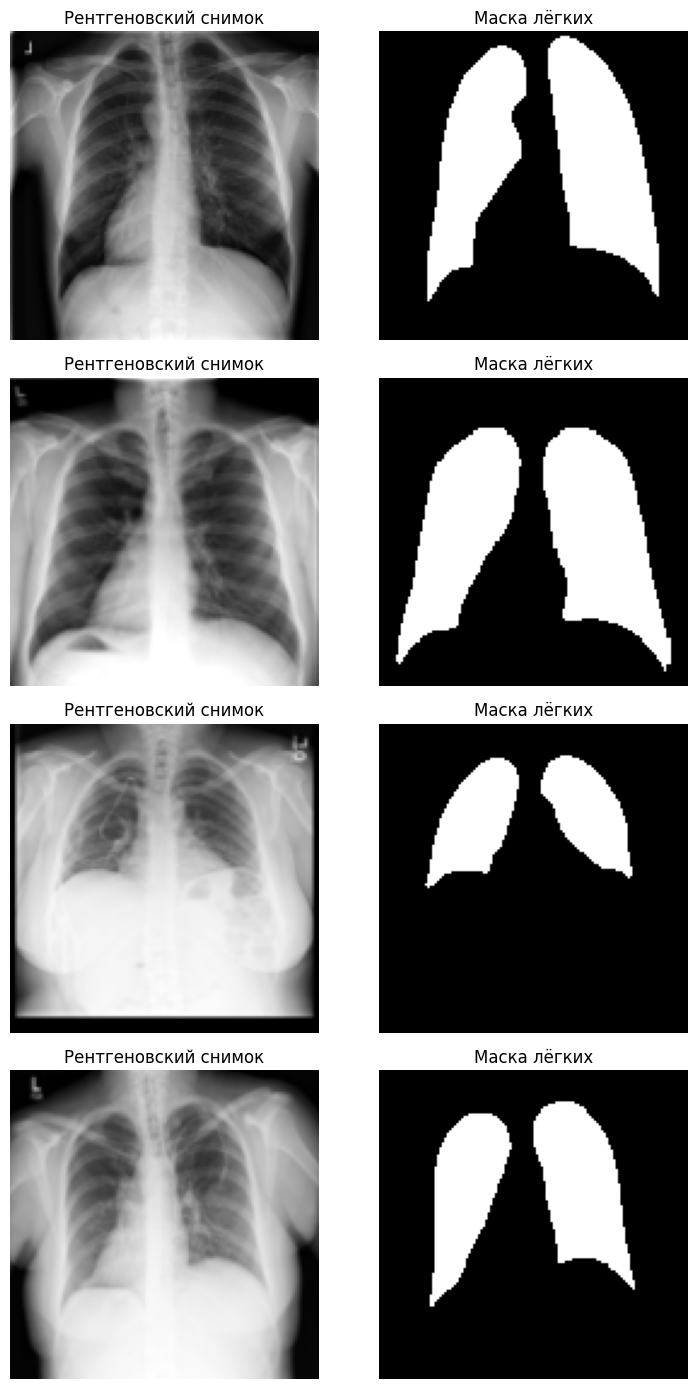

In [3]:
# 9. Установка Albumentations

%pip install -q albumentations


# 10. Дополнительные импорты

import cv2
import albumentations as A
import tensorflow as tf


# 11. Разделение выборок

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

pairs_copy = pairs.copy()

random.shuffle(
    pairs_copy
)

TRAIN_COUNT = 1200
VALID_COUNT = 200
TEST_COUNT = 100

required_count = (
    TRAIN_COUNT
    + VALID_COUNT
    + TEST_COUNT
)

if len(pairs_copy) < required_count:
    raise RuntimeError(
        "В датасете недостаточно пар."
    )

train_pairs = pairs_copy[
    :TRAIN_COUNT
]

valid_pairs = pairs_copy[
    TRAIN_COUNT:
    TRAIN_COUNT + VALID_COUNT
]

test_pairs = pairs_copy[
    TRAIN_COUNT + VALID_COUNT:
    required_count
]

print(
    "Train:",
    len(train_pairs)
)

print(
    "Validation:",
    len(valid_pairs)
)

print(
    "Test:",
    len(test_pairs)
)



# 12. Настройки изображений

IMAGE_SIZE = 128
BATCH_SIZE = 8

IMAGE_SHAPE = (
    IMAGE_SIZE,
    IMAGE_SIZE,
    1,
)

print(
    "Размер входа:",
    IMAGE_SHAPE
)

print(
    "Batch size:",
    BATCH_SIZE
)


# 13. Аугментация

train_transform = A.Compose([
    A.HorizontalFlip(
        p=0.5
    ),

    A.Rotate(
        limit=10,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5,
    ),

    A.Affine(
        translate_percent={
            "x": (-0.05, 0.05),
            "y": (-0.05, 0.05),
        },
        scale=(
            0.95,
            1.05,
        ),
        p=0.5,
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.4,
    ),
])

print(
    "Аугментация подготовлена."
)


# 14. Загрузка изображения и маски

def load_pair(
    image_path,
    mask_path,
):

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE,
    )

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE,
    )

    if image is None:
        raise ValueError(
            f"Не удалось открыть {image_path}"
        )

    if mask is None:
        raise ValueError(
            f"Не удалось открыть {mask_path}"
        )

    image = cv2.resize(
        image,
        (
            IMAGE_SIZE,
            IMAGE_SIZE,
        ),
        interpolation=cv2.INTER_AREA,
    )

    mask = cv2.resize(
        mask,
        (
            IMAGE_SIZE,
            IMAGE_SIZE,
        ),
        interpolation=cv2.INTER_NEAREST,
    )

    image = (
        image.astype(
            np.float32
        )
        / 255.0
    )

    mask = (
        mask.astype(
            np.float32
        )
        / 255.0
    )

    mask = (
        mask > 0.5
    ).astype(
        np.float32
    )

    image = np.expand_dims(
        image,
        axis=-1,
    )

    mask = np.expand_dims(
        mask,
        axis=-1,
    )

    return image, mask


# 15. Генератор данных

class SegmentationSequence(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        pairs,
        batch_size=8,
        augment=False,
        shuffle=True,
        **kwargs,
    ):

        super().__init__(
            **kwargs
        )

        self.pairs = list(
            pairs
        )

        self.batch_size = (
            batch_size
        )

        self.augment = augment
        self.shuffle = shuffle

        self.indices = np.arange(
            len(self.pairs)
        )

        self.on_epoch_end()

    def __len__(self):

        return int(
            np.ceil(
                len(self.pairs)
                / self.batch_size
            )
        )

    def __getitem__(
        self,
        index,
    ):

        start = (
            index
            * self.batch_size
        )

        end = min(
            start
            + self.batch_size,
            len(self.pairs),
        )

        batch_indices = (
            self.indices[
                start:end
            ]
        )

        images = []
        masks = []

        for pair_index in batch_indices:

            image_path, mask_path = (
                self.pairs[
                    pair_index
                ]
            )

            image, mask = load_pair(
                image_path,
                mask_path,
            )

            if self.augment:

                transformed = (
                    train_transform(
                        image=image,
                        mask=mask,
                    )
                )

                image = transformed[
                    "image"
                ]

                mask = transformed[
                    "mask"
                ]

            images.append(
                image
            )

            masks.append(
                mask
            )

        return (
            np.asarray(
                images,
                dtype=np.float32,
            ),
            np.asarray(
                masks,
                dtype=np.float32,
            ),
        )

    def on_epoch_end(self):

        if self.shuffle:

            np.random.shuffle(
                self.indices
            )


# 16. Создание генераторов

train_generator = (
    SegmentationSequence(
        train_pairs,
        batch_size=BATCH_SIZE,
        augment=True,
        shuffle=True,
    )
)

valid_generator = (
    SegmentationSequence(
        valid_pairs,
        batch_size=BATCH_SIZE,
        augment=False,
        shuffle=False,
    )
)

test_generator = (
    SegmentationSequence(
        test_pairs,
        batch_size=BATCH_SIZE,
        augment=False,
        shuffle=False,
    )
)

print(
    "Train batches:",
    len(train_generator)
)

print(
    "Validation batches:",
    len(valid_generator)
)

print(
    "Test batches:",
    len(test_generator)
)



# 17. Проверка генератора

images, masks = (
    train_generator[0]
)

print(
    "Images:",
    images.shape
)

print(
    "Masks:",
    masks.shape
)

print(
    "Image min/max:",
    images.min(),
    images.max(),
)

print(
    "Mask values:",
    np.unique(masks)
)


# 18. Проверка аугментации

images, masks = (
    train_generator[0]
)

fig, axes = plt.subplots(
    4,
    2,
    figsize=(8, 14),
)

for row in range(4):

    axes[
        row,
        0
    ].imshow(
        images[row, :, :, 0],
        cmap="gray",
    )

    axes[
        row,
        0
    ].set_title(
        "Рентгеновский снимок"
    )

    axes[
        row,
        1
    ].imshow(
        masks[row, :, :, 0],
        cmap="gray",
    )

    axes[
        row,
        1
    ].set_title(
        "Маска лёгких"
    )

    axes[
        row,
        0
    ].axis("off")

    axes[
        row,
        1
    ].axis("off")

plt.tight_layout()
plt.show()




In [4]:
# 19. Импорты для модели

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Activation,
    BatchNormalization,
    Concatenate,
    Conv2D,
    Conv2DTranspose,
    Input,
    MaxPooling2D,
)
from tensorflow.keras.optimizers import Adam



# 20. Метрика Dice

def dice_coefficient(
    y_true,
    y_pred,
    smooth=1e-6,
):

    y_true = tf.cast(
        y_true,
        tf.float32,
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32,
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=[1, 2, 3],
    )

    total = (
        tf.reduce_sum(
            y_true,
            axis=[1, 2, 3],
        )
        + tf.reduce_sum(
            y_pred,
            axis=[1, 2, 3],
        )
    )

    dice = (
        2.0 * intersection
        + smooth
    ) / (
        total
        + smooth
    )

    return tf.reduce_mean(
        dice
    )


# 21. Функция ошибки

def dice_loss(
    y_true,
    y_pred,
):

    return (
        1.0
        - dice_coefficient(
            y_true,
            y_pred,
        )
    )


def combined_loss(
    y_true,
    y_pred,
):

    bce = (
        tf.keras.losses.binary_crossentropy(
            y_true,
            y_pred,
        )
    )

    bce = tf.reduce_mean(
        bce
    )

    return (
        bce
        + dice_loss(
            y_true,
            y_pred,
        )
    )



# 22. Сверточный блок

def convolution_block(
    inputs,
    filters,
):

    x = Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
    )(inputs)

    x = BatchNormalization()(
        x
    )

    x = Activation(
        "relu"
    )(x)

    x = Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal",
    )(x)

    x = BatchNormalization()(
        x
    )

    x = Activation(
        "relu"
    )(x)

    return x



# 23. Повышение размерности

def upsample_block(
    inputs,
    filters,
):

    return Conv2DTranspose(
        filters,
        kernel_size=2,
        strides=2,
        padding="same",
    )(inputs)



# 24. Архитектура U-Net++

def create_unet_plus_plus(
    input_shape=(128, 128, 1),
    base_filters=16,
):

    inputs = Input(
        shape=input_shape,
        name="input_image",
    )

    # Первый уровень
    x00 = convolution_block(
        inputs,
        base_filters,
    )

    # Второй уровень
    x10 = convolution_block(
        MaxPooling2D(2)(x00),
        base_filters * 2,
    )

    # Третий уровень
    x20 = convolution_block(
        MaxPooling2D(2)(x10),
        base_filters * 4,
    )

    # Четвертый уровень
    x30 = convolution_block(
        MaxPooling2D(2)(x20),
        base_filters * 8,
    )

    # Нижний уровень
    x40 = convolution_block(
        MaxPooling2D(2)(x30),
        base_filters * 16,
    )

    # Первый вложенный уровень
    x01 = convolution_block(
        Concatenate()([
            x00,
            upsample_block(
                x10,
                base_filters,
            ),
        ]),
        base_filters,
    )

    x11 = convolution_block(
        Concatenate()([
            x10,
            upsample_block(
                x20,
                base_filters * 2,
            ),
        ]),
        base_filters * 2,
    )

    x21 = convolution_block(
        Concatenate()([
            x20,
            upsample_block(
                x30,
                base_filters * 4,
            ),
        ]),
        base_filters * 4,
    )

    x31 = convolution_block(
        Concatenate()([
            x30,
            upsample_block(
                x40,
                base_filters * 8,
            ),
        ]),
        base_filters * 8,
    )

    # Второй вложенный уровень
    x02 = convolution_block(
        Concatenate()([
            x00,
            x01,
            upsample_block(
                x11,
                base_filters,
            ),
        ]),
        base_filters,
    )

    x12 = convolution_block(
        Concatenate()([
            x10,
            x11,
            upsample_block(
                x21,
                base_filters * 2,
            ),
        ]),
        base_filters * 2,
    )

    x22 = convolution_block(
        Concatenate()([
            x20,
            x21,
            upsample_block(
                x31,
                base_filters * 4,
            ),
        ]),
        base_filters * 4,
    )

    # Третий вложенный уровень
    x03 = convolution_block(
        Concatenate()([
            x00,
            x01,
            x02,
            upsample_block(
                x12,
                base_filters,
            ),
        ]),
        base_filters,
    )

    x13 = convolution_block(
        Concatenate()([
            x10,
            x11,
            x12,
            upsample_block(
                x22,
                base_filters * 2,
            ),
        ]),
        base_filters * 2,
    )

    # Четвертый вложенный уровень
    x04 = convolution_block(
        Concatenate()([
            x00,
            x01,
            x02,
            x03,
            upsample_block(
                x13,
                base_filters,
            ),
        ]),
        base_filters,
    )

    # Бинарная маска
    outputs = Conv2D(
        1,
        kernel_size=1,
        padding="same",
        activation="sigmoid",
        name="lung_mask",
    )(x04)

    return Model(
        inputs=inputs,
        outputs=outputs,
        name="UNetPlusPlus",
    )



# 25. Создание модели

model = create_unet_plus_plus(
    input_shape=IMAGE_SHAPE,
    base_filters=16,
)

model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss=combined_loss,
    metrics=[
        "binary_accuracy",
        dice_coefficient,
    ],
)

model.summary()



# 26. Проверка модели

sample_images, sample_masks = (
    train_generator[0]
)

sample_prediction = model(
    sample_images,
    training=False,
)

print(
    "Вход:",
    sample_images.shape
)

print(
    "Маски:",
    sample_masks.shape
)

print(
    "Предсказание:",
    sample_prediction.shape
)

print(
    "Диапазон предсказаний:",
    float(
        tf.reduce_min(
            sample_prediction
        )
    ),
    "-",
    float(
        tf.reduce_max(
            sample_prediction
        )
    ),
)





Model: "UNetPlusPlus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_image[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]  

 Total params: 2,268,897 (8.66 MB)

 Trainable params: 2,265,249 (8.64 MB)

 Non-trainable params: 3,648 (14.25 KB)

Вход: (8, 128, 128, 1)
Маски: (8, 128, 128, 1)
Предсказание: (8, 128, 128, 1)
Диапазон предсказаний: 0.37363624572753906 - 0.5860124826431274


Epoch 1/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - binary_accuracy: 0.9111 - dice_coefficient: 0.6758 - loss: 0.5808
Epoch 1: val_loss improved from None to 0.49808, saving model to unet_plus_plus_best.weights.h5

Epoch 1: finished saving model to unet_plus_plus_best.weights.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 449s 3s/step - binary_accuracy: 0.9575 - dice_coefficient: 0.7867 - loss: 0.3681 - val_binary_accuracy: 0.9089 - val_dice_coefficient: 0.7708 - val_loss: 0.4981 - learning_rate: 0.0010
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - binary_accuracy: 0.9841 - dice_coefficient: 0.9158 - loss: 0.1434
Epoch 2: val_loss improved from 0.49808 to 0.13822, saving model to unet_plus_plus_best.weights.h5

Epoch 2: finished saving model to unet_plus_plus_best.weights.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - binary_accuracy: 0.9841 - dice_coefficient: 0.9264 - loss: 0.1283 - val_binary_accuracy: 0.9780 - val_dice_coefficient: 0.9278 - val_loss: 0.1382 - learning_rate: 0.0010
Epoch 3

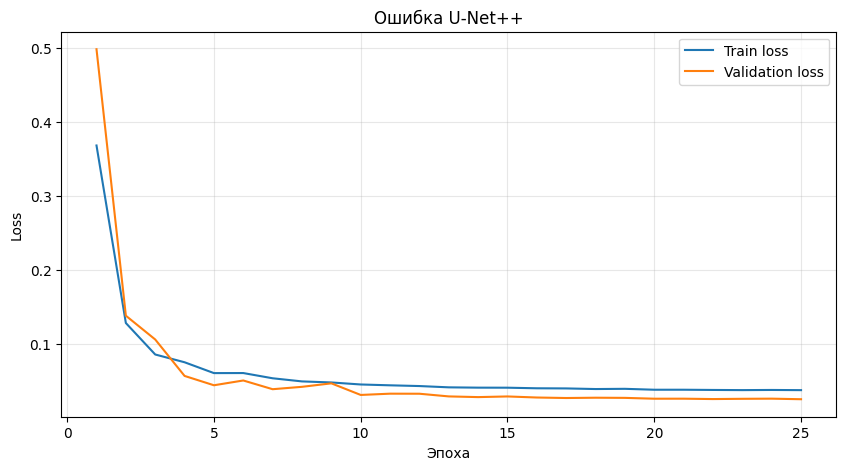

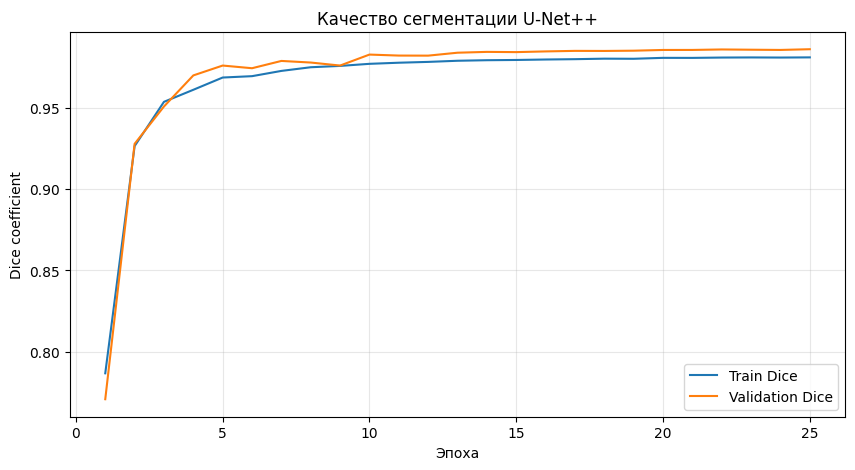

Лучшие веса загружены.
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 539ms/step - binary_accuracy: 0.9951 - dice_coefficient: 0.9852 - loss: 0.0268

Test loss: 0.0268
Test accuracy: 0.9951
Test Dice: 0.9852


In [5]:
# 27. Коллбэки

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)

checkpoint = ModelCheckpoint(
    "unet_plus_plus_best.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)

callbacks = [
    early_stopping,
    reduce_lr,
    checkpoint,
]



# 28. Обучение модели

EPOCHS = 25

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)



# 29. Результат обучения

completed_epochs = len(
    history.history["loss"]
)

print(
    "Выполнено эпох:",
    completed_epochs
)

print(
    "Лучшая validation loss:",
    min(
        history.history[
            "val_loss"
        ]
    )
)

print(
    "Лучший validation Dice:",
    max(
        history.history[
            "val_dice_coefficient"
        ]
    )
)




# 30. График функции ошибки

epochs_range = range(
    1,
    completed_epochs + 1,
)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs_range,
    history.history["loss"],
    label="Train loss",
)

plt.plot(
    epochs_range,
    history.history["val_loss"],
    label="Validation loss",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Ошибка U-Net++"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.show()



# 31. График Dice coefficient

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epochs_range,
    history.history[
        "dice_coefficient"
    ],
    label="Train Dice",
)

plt.plot(
    epochs_range,
    history.history[
        "val_dice_coefficient"
    ],
    label="Validation Dice",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Dice coefficient"
)

plt.title(
    "Качество сегментации U-Net++"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.show()



# 32. Загрузка лучших весов

model.load_weights(
    "unet_plus_plus_best.weights.h5"
)

print(
    "Лучшие веса загружены."
)


# 33. Оценка на тестовой выборке

test_results = model.evaluate(
    test_generator,
    verbose=1,
)

print()
print(
    f"Test loss: "
    f"{test_results[0]:.4f}"
)

print(
    f"Test accuracy: "
    f"{test_results[1]:.4f}"
)

print(
    f"Test Dice: "
    f"{test_results[2]:.4f}"
)





Изображения: (10, 128, 128, 1)
Маски: (10, 128, 128, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Предсказания: (10, 128, 128, 1)
Значения маски: [0. 1.]
Пример 1: Dice = 0.9814
Пример 2: Dice = 0.9950
Пример 3: Dice = 0.9818
Пример 4: Dice = 0.9926
Пример 5: Dice = 0.9939
Пример 6: Dice = 0.9921
Пример 7: Dice = 0.9851
Пример 8: Dice = 0.9854
Пример 9: Dice = 0.9948
Пример 10: Dice = 0.9912

Средний Dice: 0.9893


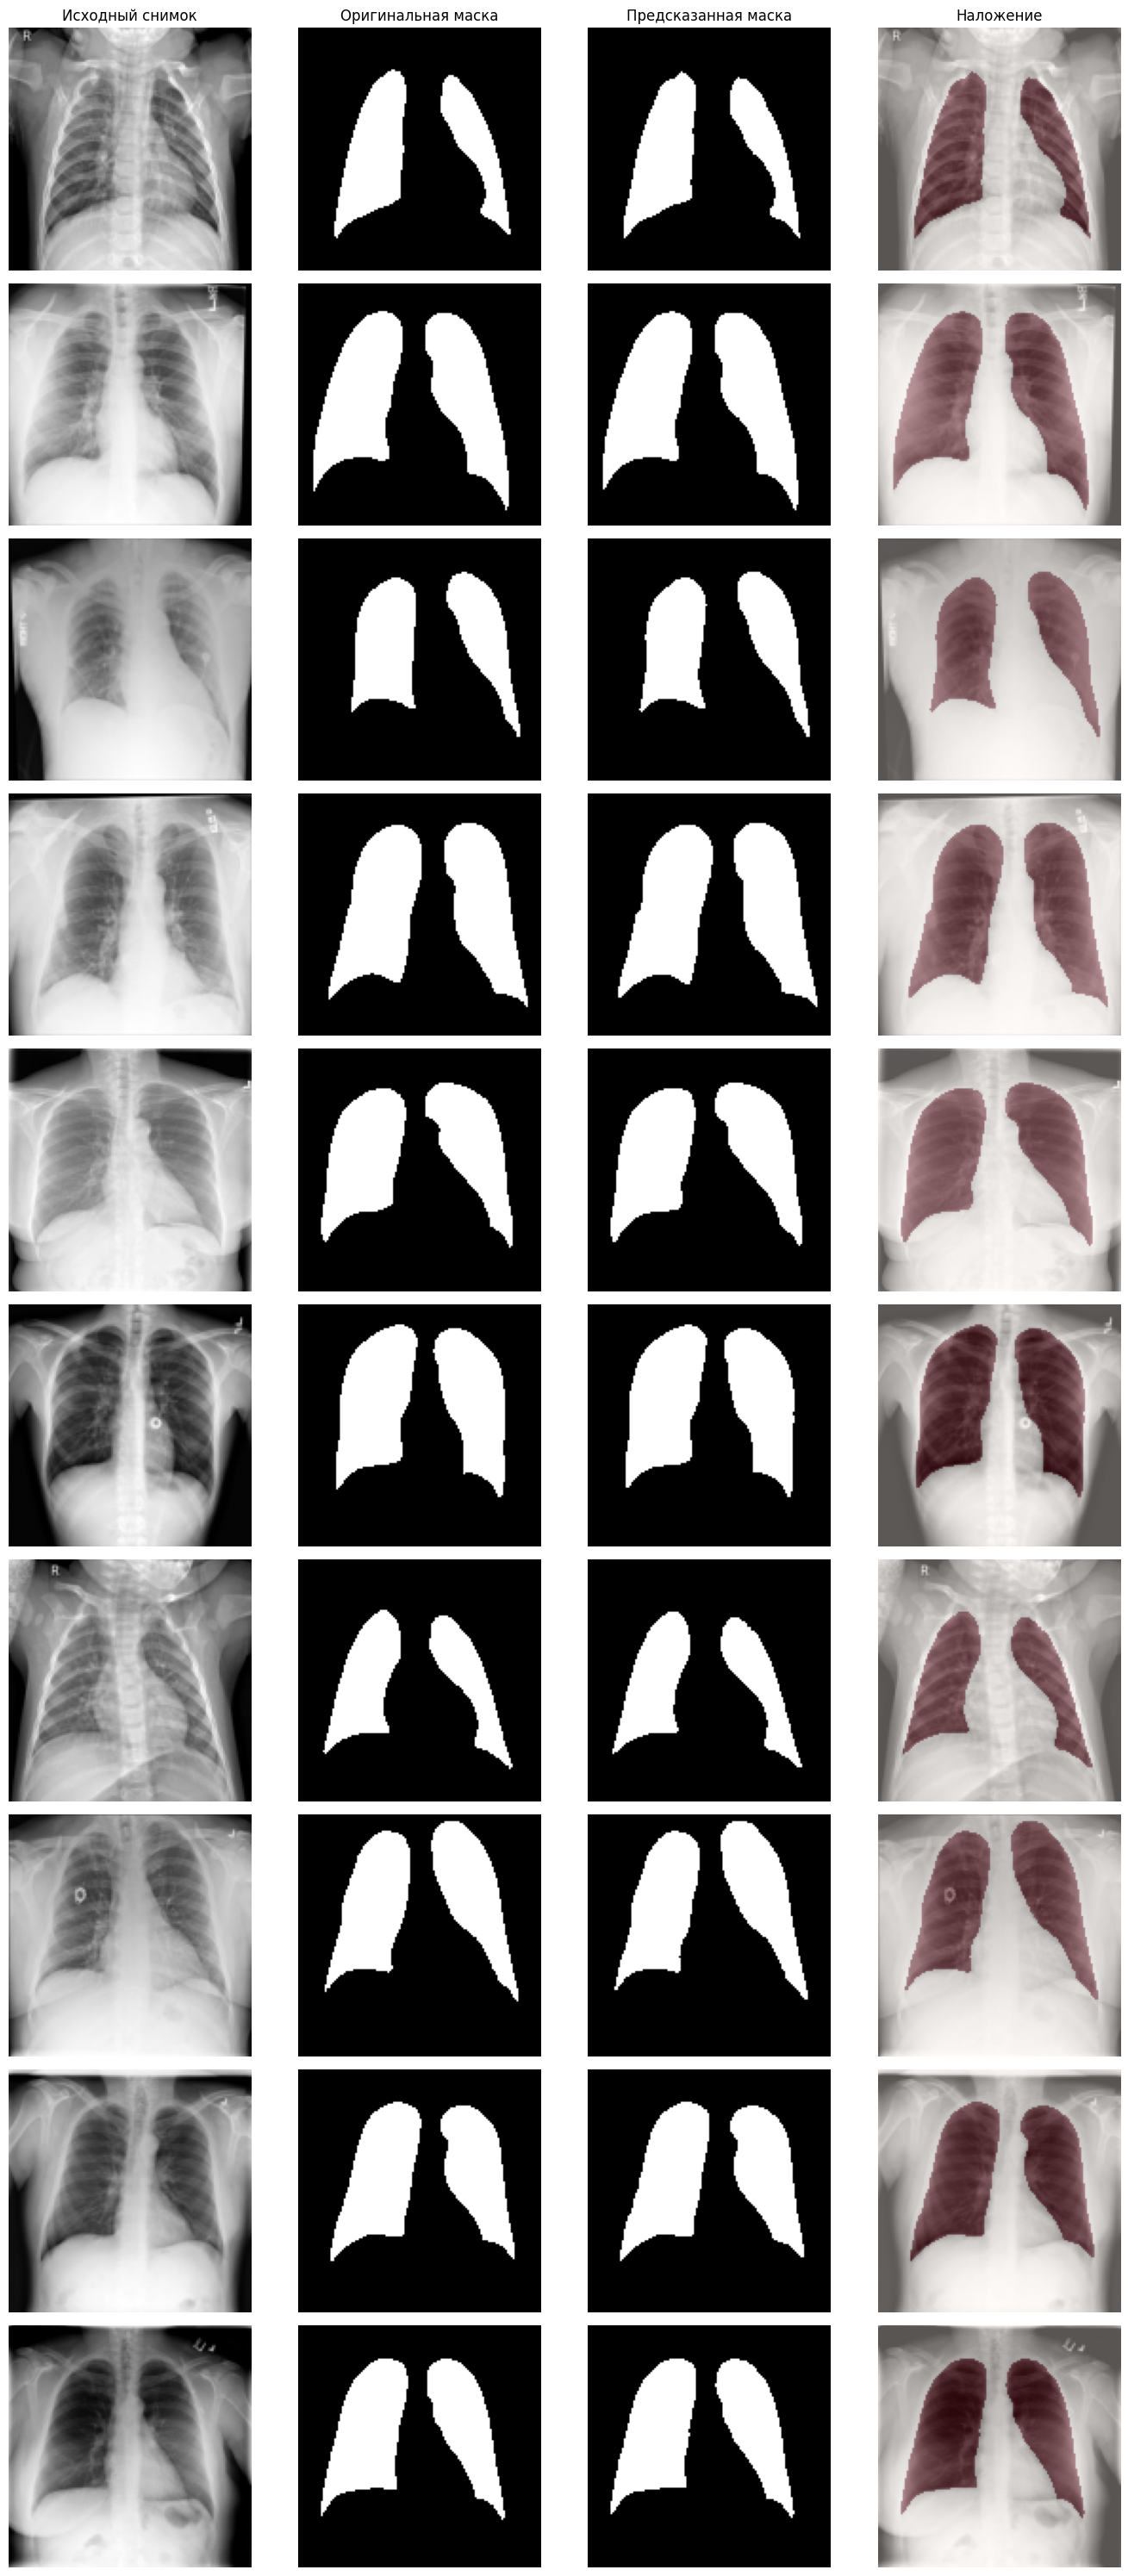

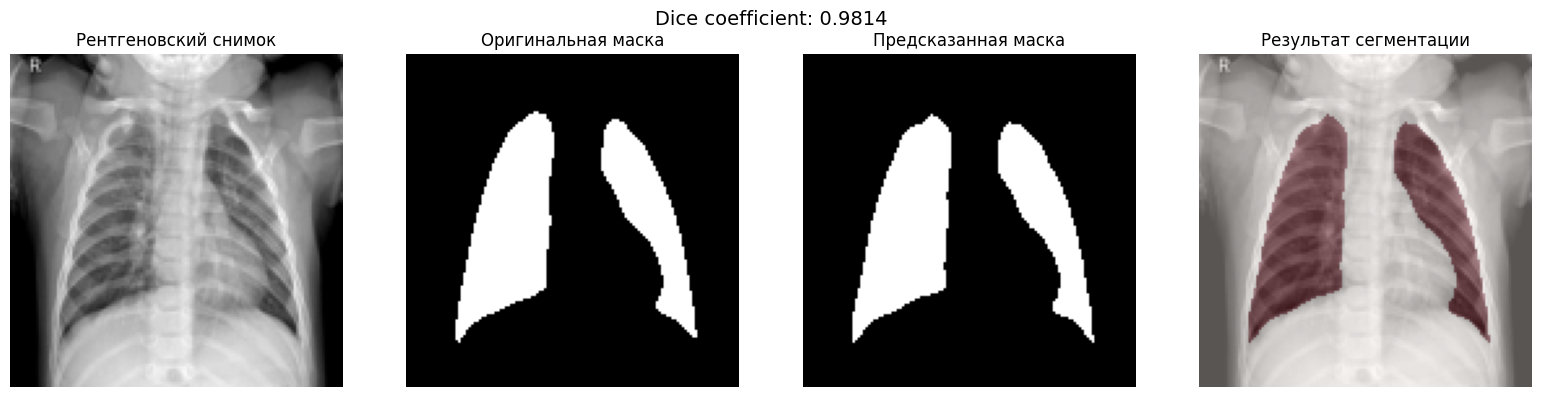

Веса U-Net++ сохранены.
Архитектура: U-Net++
Размер изображений: 128 x 128
Обучающих примеров: 1200
Проверочных примеров: 200
Тестовых примеров: 100
Количество эпох: 25
Средний Dice для 10 примеров: 0.9893


In [6]:
# 34. Подготовка тестовых примеров

SHOW_COUNT = 10

sample_pairs = test_pairs[
    :SHOW_COUNT
]

test_images = []
test_masks = []

for image_path, mask_path in sample_pairs:

    image, mask = load_pair(
        image_path,
        mask_path,
    )

    test_images.append(
        image
    )

    test_masks.append(
        mask
    )

test_images = np.asarray(
    test_images,
    dtype=np.float32,
)

test_masks = np.asarray(
    test_masks,
    dtype=np.float32,
)

print(
    "Изображения:",
    test_images.shape
)

print(
    "Маски:",
    test_masks.shape
)


# 35. Предсказание масок

predictions = model.predict(
    test_images,
    verbose=1,
)

predicted_masks = (
    predictions >= 0.5
).astype(
    np.float32
)

print(
    "Предсказания:",
    predictions.shape
)

print(
    "Значения маски:",
    np.unique(
        predicted_masks
    )
)



# 36. Dice для тестовых примеров

def calculate_dice(
    true_mask,
    predicted_mask,
    smooth=1e-6,
):

    true_mask = (
        true_mask.flatten()
    )

    predicted_mask = (
        predicted_mask.flatten()
    )

    intersection = np.sum(
        true_mask
        * predicted_mask
    )

    return (
        2.0 * intersection
        + smooth
    ) / (
        np.sum(true_mask)
        + np.sum(predicted_mask)
        + smooth
    )


dice_scores = []

for index in range(
    SHOW_COUNT
):

    score = calculate_dice(
        test_masks[index],
        predicted_masks[index],
    )

    dice_scores.append(
        score
    )

    print(
        f"Пример {index + 1}: "
        f"Dice = {score:.4f}"
    )

print()
print(
    "Средний Dice:",
    f"{np.mean(dice_scores):.4f}"
)


# 37. Результаты сегментации

fig, axes = plt.subplots(
    SHOW_COUNT,
    4,
    figsize=(
        14,
        SHOW_COUNT * 3,
    ),
)

titles = [
    "Исходный снимок",
    "Оригинальная маска",
    "Предсказанная маска",
    "Наложение",
]

for column, title in enumerate(
    titles
):

    axes[
        0,
        column
    ].set_title(
        title,
        fontsize=12,
    )


for row in range(
    SHOW_COUNT
):

    image = test_images[
        row,
        :,
        :,
        0
    ]

    true_mask = test_masks[
        row,
        :,
        :,
        0
    ]

    predicted_mask = predicted_masks[
        row,
        :,
        :,
        0
    ]

    axes[
        row,
        0
    ].imshow(
        image,
        cmap="gray",
    )

    axes[
        row,
        1
    ].imshow(
        true_mask,
        cmap="gray",
    )

    axes[
        row,
        2
    ].imshow(
        predicted_mask,
        cmap="gray",
    )

    axes[
        row,
        3
    ].imshow(
        image,
        cmap="gray",
    )

    axes[
        row,
        3
    ].imshow(
        predicted_mask,
        alpha=0.35,
        cmap="Reds",
    )

    axes[
        row,
        0
    ].set_ylabel(
        f"№ {row + 1}\n"
        f"Dice: "
        f"{dice_scores[row]:.3f}",
        fontsize=9,
    )

    for column in range(
        4
    ):

        axes[
            row,
            column
        ].axis(
            "off"
        )


plt.tight_layout()
plt.show()


# 38. Отдельный пример сегментации

EXAMPLE_INDEX = 0

image = test_images[
    EXAMPLE_INDEX,
    :,
    :,
    0
]

true_mask = test_masks[
    EXAMPLE_INDEX,
    :,
    :,
    0
]

predicted_mask = predicted_masks[
    EXAMPLE_INDEX,
    :,
    :,
    0
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
)

axes[0].imshow(
    image,
    cmap="gray",
)

axes[0].set_title(
    "Рентгеновский снимок"
)

axes[1].imshow(
    true_mask,
    cmap="gray",
)

axes[1].set_title(
    "Оригинальная маска"
)

axes[2].imshow(
    predicted_mask,
    cmap="gray",
)

axes[2].set_title(
    "Предсказанная маска"
)

axes[3].imshow(
    image,
    cmap="gray",
)

axes[3].imshow(
    predicted_mask,
    alpha=0.35,
    cmap="Reds",
)

axes[3].set_title(
    "Результат сегментации"
)

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"Dice coefficient: "
    f"{dice_scores[EXAMPLE_INDEX]:.4f}",
    fontsize=14,
)

plt.tight_layout()
plt.show()


# 39. Сохранение модели

model.save_weights(
    "unet_plus_plus_final.weights.h5"
)

print(
    "Веса U-Net++ сохранены."
)


# 40. Итог

print(
    "Архитектура: U-Net++"
)

print(
    "Размер изображений:",
    f"{IMAGE_SIZE} x {IMAGE_SIZE}"
)

print(
    "Обучающих примеров:",
    len(train_pairs)
)

print(
    "Проверочных примеров:",
    len(valid_pairs)
)

print(
    "Тестовых примеров:",
    len(test_pairs)
)

print(
    "Количество эпох:",
    completed_epochs
)

print(
    f"Средний Dice "
    f"для 10 примеров: "
    f"{np.mean(dice_scores):.4f}"
)

# Выводы


Для работы использовался COVID-19 Radiography Dataset.
Из датасета были выбраны изображения пациентов с нормальным
состоянием лёгких из категории `Normal` и соответствующие им
маски лёгких.

Исходные изображения и маски были приведены к размеру
128 × 128 пикселей. Рентгеновские снимки обрабатывались
в оттенках серого.

Данные были разделены на три независимые выборки:

- 1200 изображений для обучения;
- 200 изображений для проверки;
- 100 изображений для тестирования.

Для увеличения разнообразия обучающих данных применялась
библиотека Albumentations. Использовались горизонтальное
отражение, поворот, сдвиг, масштабирование, а также изменение
яркости и контраста изображений.

Геометрические преобразования применялись одновременно
к рентгеновскому изображению и соответствующей маске,
что позволило сохранить их правильное пространственное
соответствие.

Для решения задачи была реализована архитектура U-Net++.
В отличие от классической U-Net, данная архитектура использует
вложенные плотные соединения между блоками кодировщика
и декодировщика.

Так как решалась задача бинарной сегментации, выходной слой
содержал один канал и функцию активации `sigmoid`.

Для обучения использовалась комбинированная функция ошибки,
состоящая из Binary Crossentropy и Dice Loss.

Качество сегментации дополнительно оценивалось с помощью
Dice coefficient, который показывает степень совпадения
предсказанной маски с исходной.

Для предотвращения переобучения использовался callback
EarlyStopping. Контролировалось значение `val_loss`.
Параметр `patience=5` позволял продолжать обучение ещё
несколько эпох после отсутствия улучшений, а
`restore_best_weights=True` восстанавливал веса модели
с лучшим значением функции ошибки на проверочной выборке.

Также применялся ReduceLROnPlateau, уменьшающий скорость
обучения при прекращении улучшения `val_loss`.

После обучения модель была проверена на отдельной тестовой
выборке, которая не использовалась при обучении.

Для визуальной оценки были выведены 10 рентгеновских снимков,
для каждого из которых представлены:

1. исходный рентгеновский снимок;
2. оригинальная маска лёгких;
3. маска, предсказанная моделью U-Net++;
4. предсказанная маска, наложенная на исходный снимок.
